In [1]:
import retinoto_py as fovea
args = fovea.Params(do_fovea=True, angle_start=-fovea.np.pi)
args

Params(batch_size=32, num_workers=4, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-3.141592653589793, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=150, subset_factor=1, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=3e-09, num_warmup_epochs=20, delta1=0.1, delta2=0.008, weight_decay=0.005, label_smoothing=0.01, do_full_training=True, do_augment=True, augment_proba=0.2, stochastic_depth_prob=0.7, seed=1998, shuffle=True, verbose=False)

In [2]:
# import torch
# from torchvision.io import read_image

# image_url = './images/leopard.jpg'
# image_url = './images/unexpected-visitor.jpg'
# full_image = read_image(image_url)/255.
# full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
# print(f"{type(full_image) = }, {full_image.dtype = }, {full_image.shape = }, {full_image.min()=}, {full_image.max()=}")
# print(full_image.shape, full_image_np.shape)


In [3]:
import torch
from torchvision.io import read_image

image_url = './images/unexpected-visitor.jpg'

full_image = read_image(image_url)/255.
three, H, W = full_image.shape
assert three == 3

from torchvision.transforms.functional import InterpolationMode, resize
image_size_full = 512
image_size_full = 1024
full_image = resize(full_image, image_size_full, interpolation=InterpolationMode.BILINEAR, antialias=True)[:, :image_size_full, :image_size_full]

three, H, W = full_image.shape
full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
print(f"{type(full_image) = }, {full_image.dtype = }, {full_image.shape = }, {full_image.min()=}, {full_image.max()=}")

type(full_image) = <class 'torch.Tensor'>, full_image.dtype = torch.float32, full_image.shape = torch.Size([3, 1024, 1024]), full_image.min()=tensor(0.003), full_image.max()=tensor(1.000)


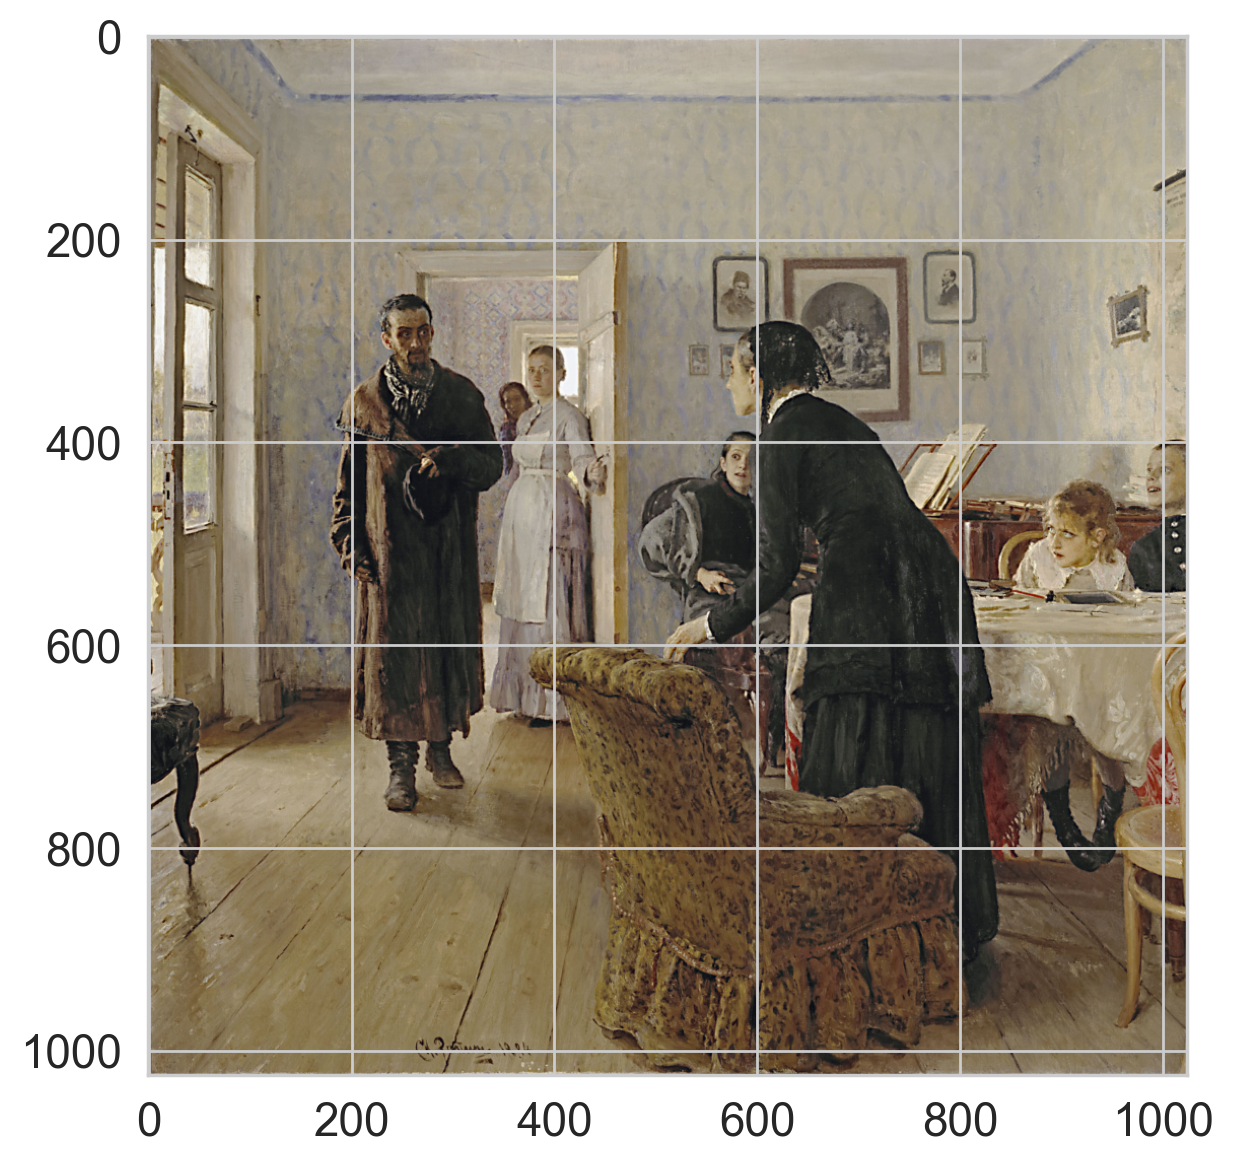

In [4]:
fig, ax = fovea.plt.subplots()
ax.imshow(full_image_np)
# ax.set_xticks([])
# ax.set_yticks([])  
fig.set_facecolor(color='white')

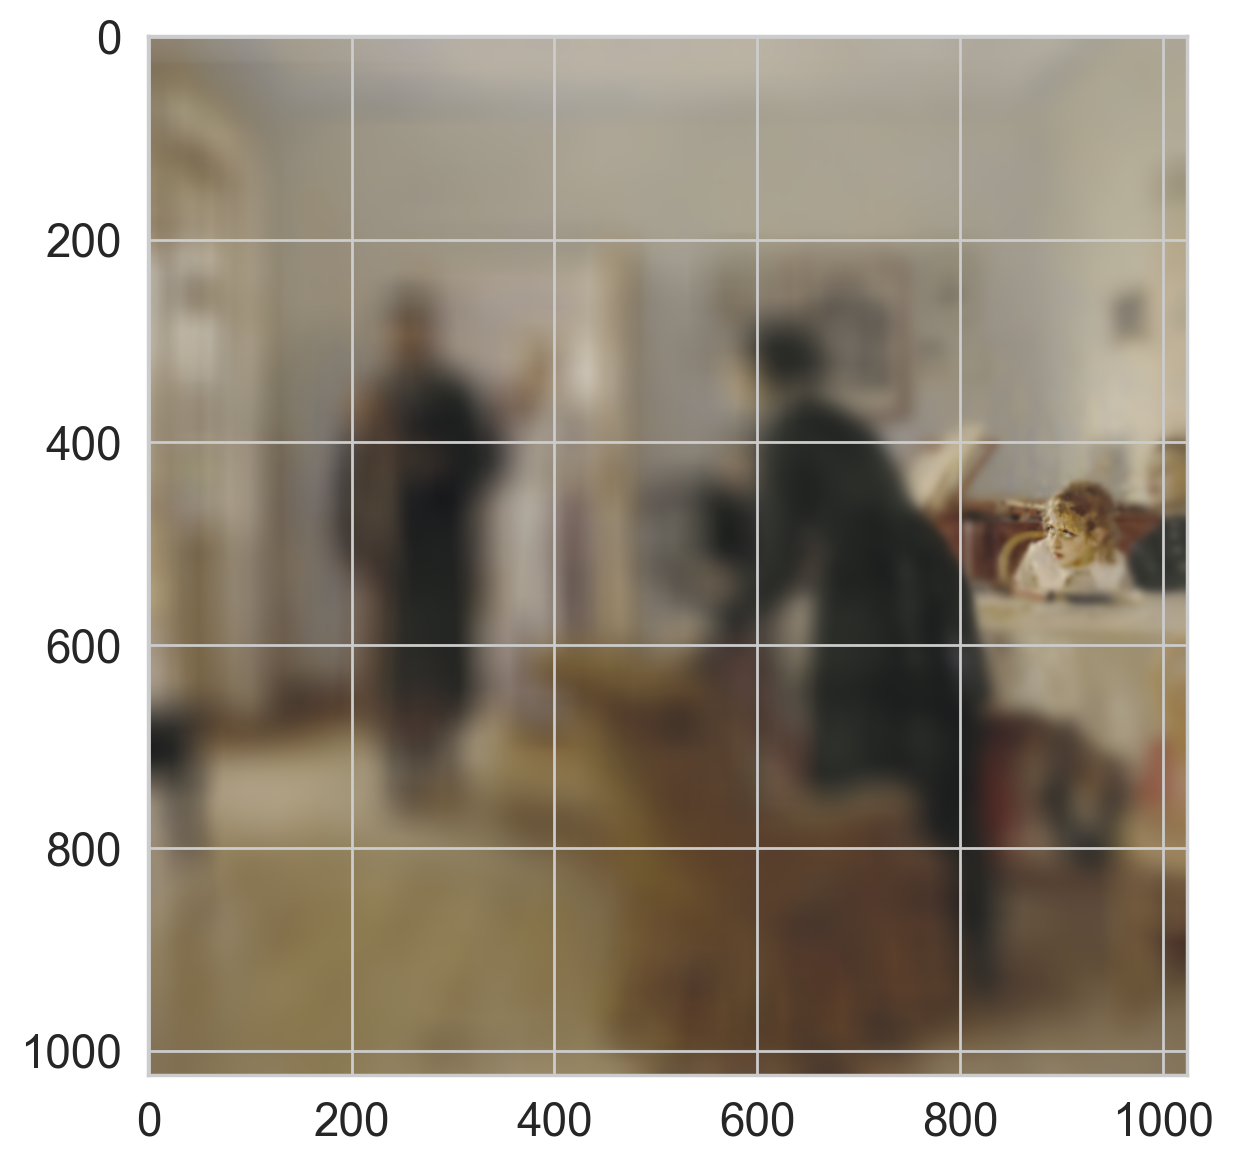

In [5]:
from torchvision.transforms import functional as TF

def apply_multiscale_blur_fast(image, sigma_map, num_levels=6):
    """
    Faster spatially-varying blur using image pyramid
    
    Args:
        image: (C, H, W) tensor
        sigma_map: (H, W) tensor with blur sigma at each pixel
        num_levels: number of blur levels in pyramid
    """
    C, H, W = image.shape
    device = image.device
    
    # Create blur levels
    blur_levels = [image]
    sigmas = [0.0]
    
    for i in range(1, num_levels):
        sigma = 2.0 ** (i - 1)
        sigmas.append(sigma)
        kernel_size = int(6 * sigma) | 1
        kernel_size = max(3, min(kernel_size, 51))
        blurred = TF.gaussian_blur(image, kernel_size, sigma=sigma)
        blur_levels.append(blurred)
    
    # Add maximum blur level
    sigmas.append(20.0)
    blur_levels.append(TF.gaussian_blur(image, 51, sigma=20.0))
    
    # Interpolate between levels based on sigma_map
    result = torch.zeros_like(image)
    sigma_map_expanded = sigma_map.unsqueeze(0).expand(C, -1, -1)  # (C, H, W)
    
    for i in range(len(sigmas) - 1):
        sigma_low = sigmas[i]
        sigma_high = sigmas[i + 1]
        
        # Calculate blend weight for this range
        weight = torch.clamp((sigma_map_expanded - sigma_low) / (sigma_high - sigma_low), 0, 1)
        
        # Blend between adjacent blur levels
        in_range = (sigma_map_expanded >= sigma_low) & (sigma_map_expanded < sigma_high)
        result += blur_levels[i] * (1 - weight) * in_range
        result += blur_levels[i + 1] * weight * in_range
    
    # Handle values at or above maximum
    max_mask = sigma_map_expanded >= sigmas[-1]
    result += blur_levels[-1] * max_mask
    
    return result


def foveate_logpolar_fast(image, center=None, eccentricity=2.0, device='cpu'):
    """
    Faster version using multi-scale pyramid
    """
    C, H, W = image.shape
    image = image.to(device)
    
    if center is None:
        center = (W / 2, H / 2)
    
    y, x = torch.meshgrid(torch.arange(H, dtype=torch.float32, device=device),
                          torch.arange(W, dtype=torch.float32, device=device),
                          indexing='ij')
    
    r = torch.sqrt((x - center[0])**2 + (y - center[1])**2)
    # sigma_map = torch.log2(r + .01) * eccentricity
    sigma_map = (r + .01) * eccentricity
    # sigma_map = torch.clamp(sigma_map, 0, 20)
    
    return apply_multiscale_blur_fast(image, sigma_map)

full_image_recode = foveate_logpolar_fast(full_image, center=(900, 480), eccentricity=.05, device='mps').cpu()
fig, ax = fovea.plt.subplots()
ax.imshow(torch.movedim(full_image_recode, (1, 2, 0), (0, 1, 2)).numpy())

visitor_face        : center=(270, 290), size=(135x135), weight=0.3
visitor_body        : center=(280, 600), size=(180x300), weight=0.05
visitor_hands       : center=(290, 420), size=(105x105), weight=0.08
mother_face         : center=(600, 360), size=(150x150), weight=0.2
wife_face           : center=(580, 420), size=(120x120), weight=0.15
boy_face            : center=(987, 430), size=(75x75), weight=0.12
girl_face           : center=(900, 480), size=(75x75), weight=0.1


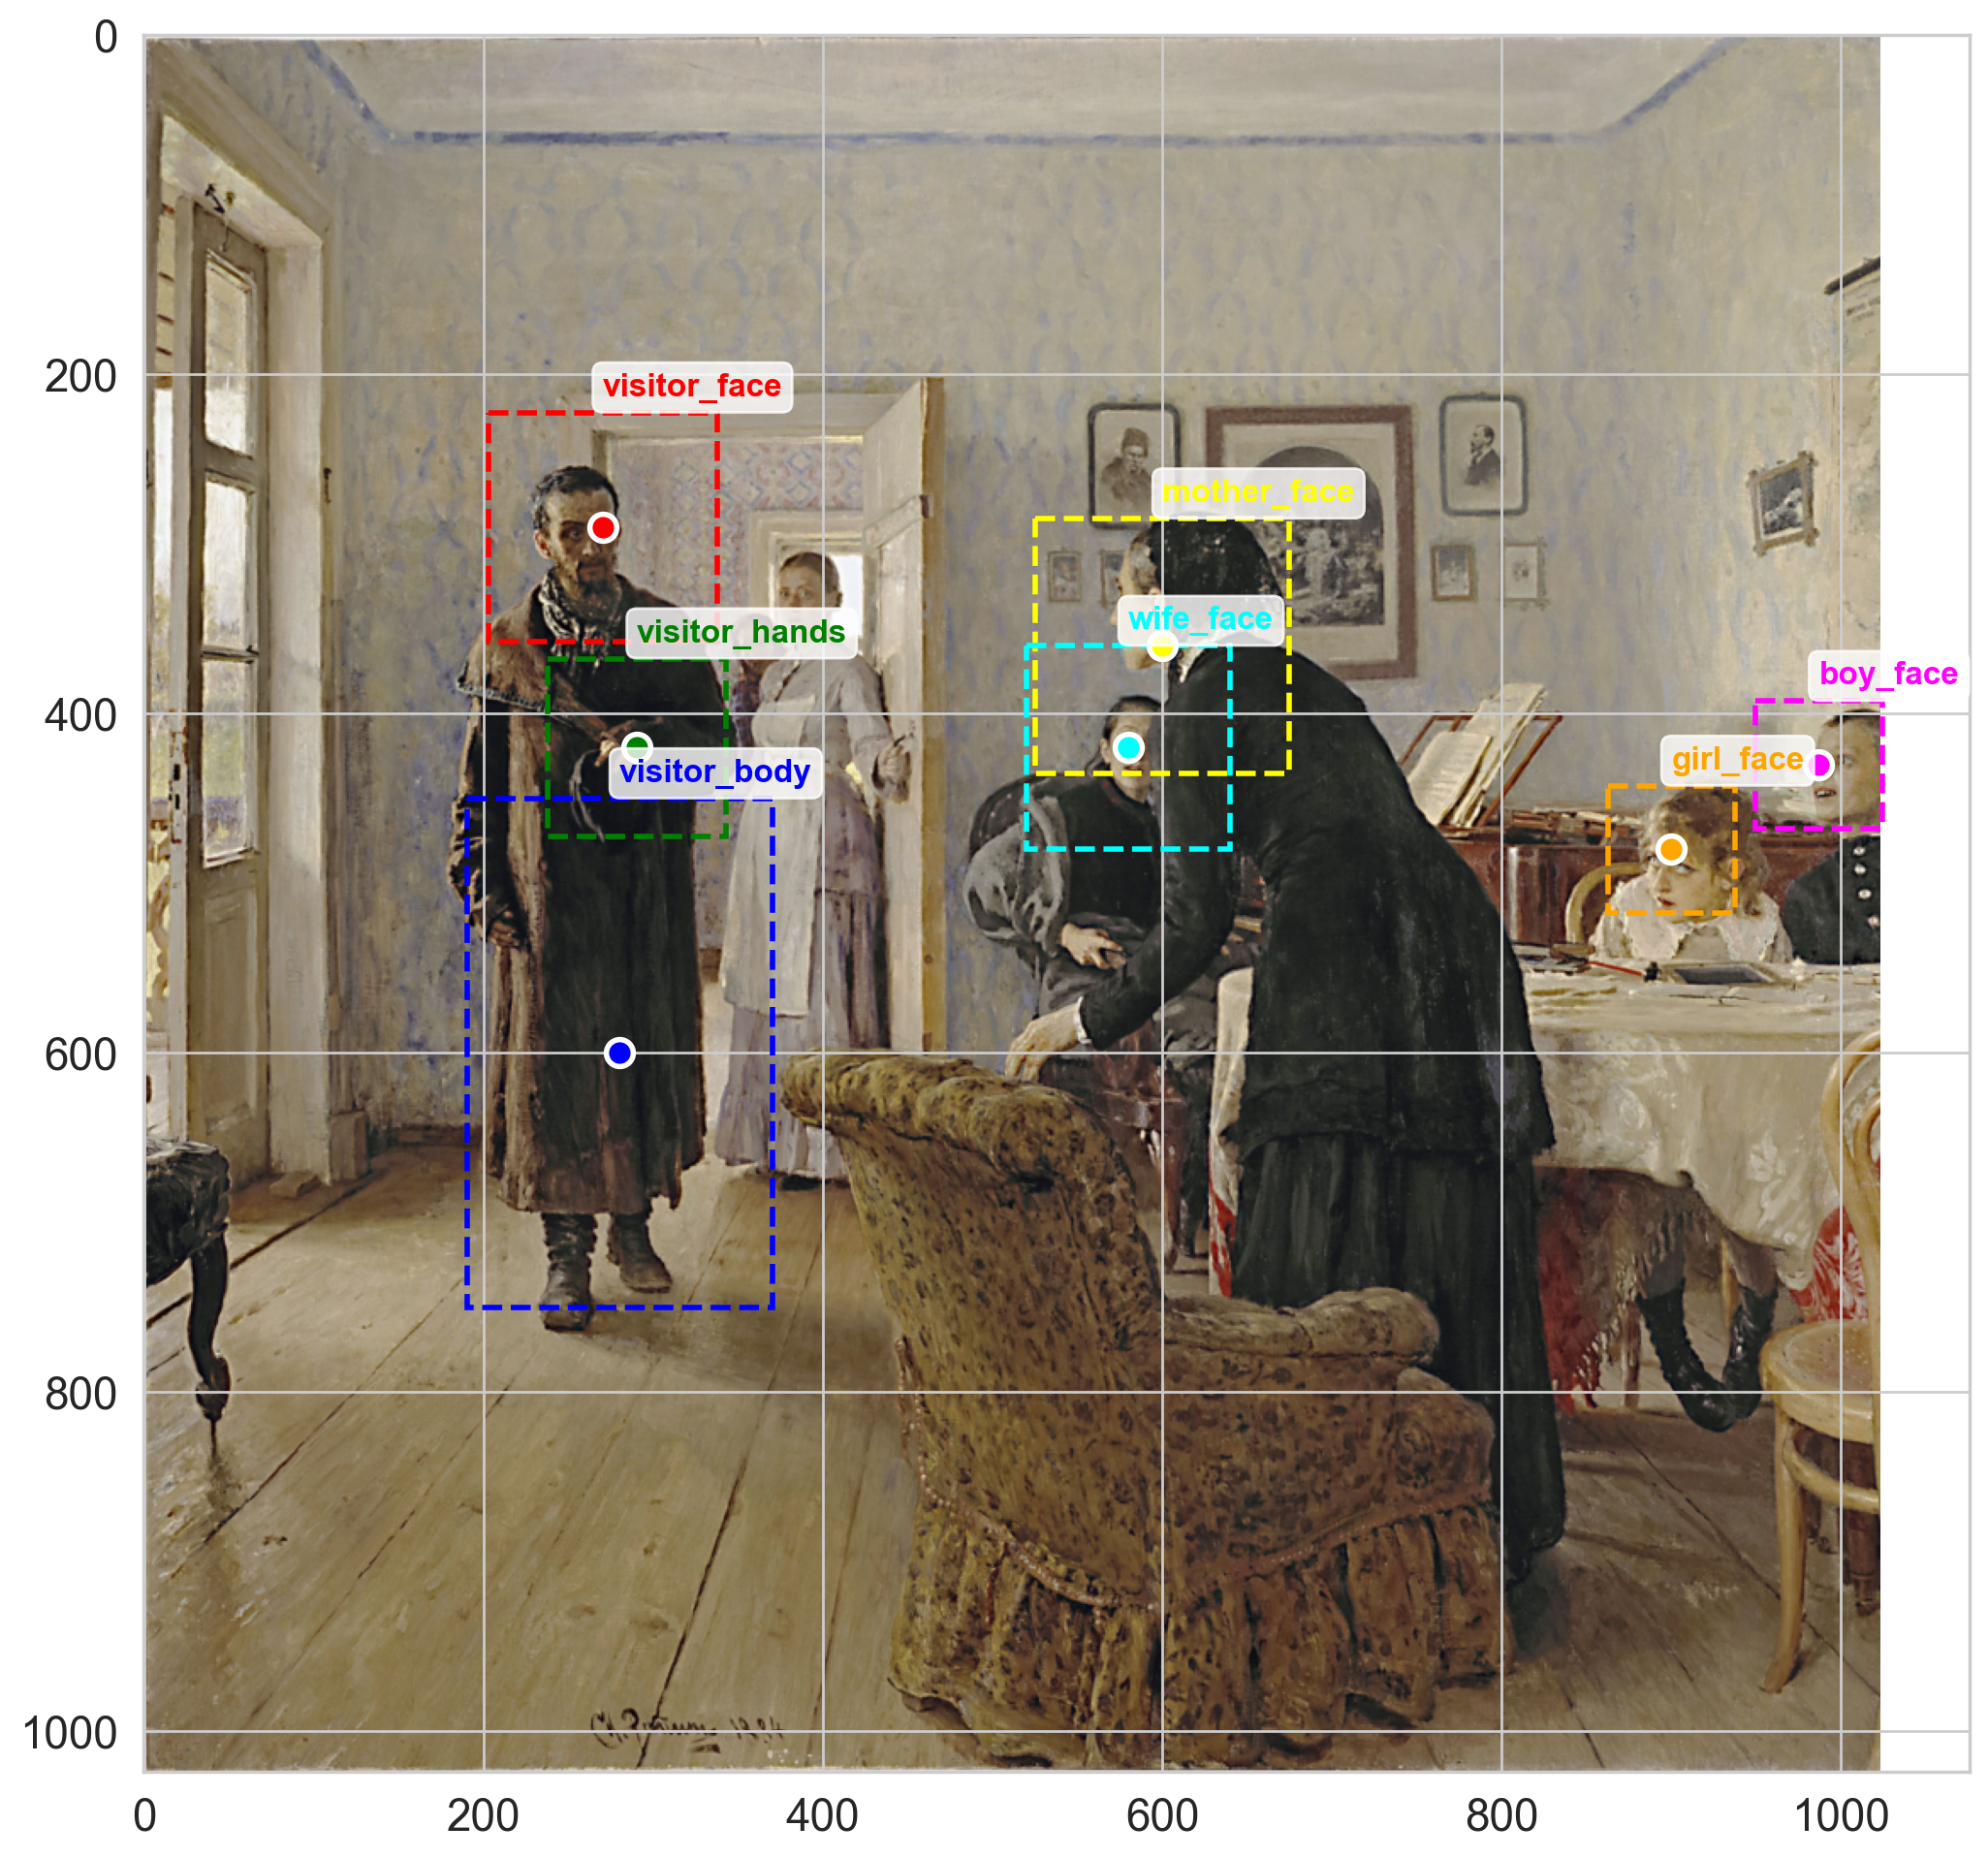

In [6]:
fig, ax = fovea.plt.subplots(figsize=(12.8, 12.8))
ax.imshow(torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy())


rois_1024 = {
    'visitor_face': (270, 290, 45, 45, 0.30),      # Left side, upper - the man standing
    'visitor_body': (280, 600, 60, 100, 0.05),     # Visitor's torso and coat
    'visitor_hands': (290, 420, 35, 35, 0.08),     # Visitor's hands area
    'mother_face': (600, 360, 50, 50, 0.20),       # Center-right, the woman in black
    'wife_face': (580, 420, 40, 40, 0.15),         # Far right, woman standing
    'boy_face': (987, 430, 25, 25, 0.12),          # Lower center-right, boy at table
    'girl_face': (900, 480, 25, 25, 0.10),         # Bottom center, girl in foreground
    # 'maid_face': (420, 320, 25, 25, 0.12),          # NEW: Maid in doorway behind visitor
}

import matplotlib.patches as patches
colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta', 'orange']

for (roi_name, (cx, cy, sx, sy, weight)), color in zip(rois_1024.items(), colors):
    # Convert normalized coordinates to pixels
    center_x = cx
    center_y = cy
    
    # ROI size in pixels (3 standard deviations = ~99% of samples)
    width_px = sx * 3
    height_px = sy * 3
        
    # Rectangle bottom-left corner
    rect_x = center_x - width_px / 2
    rect_y = center_y - height_px / 2
    
    # Draw rectangle
    rect = patches.Rectangle(
        (rect_x, rect_y), width_px, height_px,
        linewidth=2, edgecolor=color, facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    
    # Draw center point
    ax.plot(center_x, center_y, 'o', color=color, markersize=10, 
           markeredgecolor='white', markeredgewidth=2)
    
    # Add label
    ax.text(center_x, rect_y - 10, roi_name, 
           color=color, fontsize=12, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    print(f"{roi_name:20s}: center=({center_x:.0f}, {center_y:.0f}), size=({width_px:.0f}x{height_px:.0f}), weight={weight}")


In [ ]:
import numpy as np
import random

three, H, W = full_image.shape

def generate_fixations_repin(width=W, height=H, num_fixations=300, 
                             hazard_rate = .3, # chance to jump to new ROI
                             blend = 0.,  # 70% new ROI, 30% from previous position
                             seed=2018):
    """
    Generate fixation points for Repin's "An Unexpected Visitor"
    Based on Yarbus eye-tracking studies
    
    Returns: list of (x, y) tuples in pixel coordinates
    """
    np.random.seed(seed=seed)
    random.seed(seed)
    
    # Define regions of interest (ROI) in pixels
    rois = {
        'visitor_face': (270, 290, 45, 45, 0.30),      # Left side, upper - the man standing
        'visitor_body': (280, 600, 60, 100, 0.05),     # Visitor's torso and coat
        'visitor_hands': (290, 420, 35, 35, 0.08),     # Visitor's hands area
        'mother_face': (600, 360, 50, 50, 0.20),       # Center-right, the woman in black
        'wife_face': (580, 420, 40, 40, 0.15),         # Far right, woman standing
        'boy_face': (987, 430, 25, 25, 0.12),          # Lower center-right, boy at table
        'girl_face': (900, 480, 25, 25, 0.10),         # Bottom center, girl in foreground
    }

    # Convert weights to probabilities
    total_weight = sum(roi[4] for roi in rois.values())
    roi_probs = [roi[4] / total_weight for roi in rois.values()]
    roi_names = list(rois.keys())
    
    fixations = []
    
    # Start with initial fixation near center of visitor's face
    current_roi = 'visitor_face'
    cx, cy, sx, sy, _ = rois[current_roi]
    x = int((cx + np.random.randn() * sx))
    y = int((cy + np.random.randn() * sy))
    fixations.append((np.clip(x, 0, width-1), np.clip(y, 0, height-1)))
    
    for i in range(1, num_fixations):
        # Decide whether to stay in current ROI or jump to another
        if random.random() < hazard_rate: 
            # Choose next ROI based on weights
            current_roi = np.random.choice(roi_names, p=roi_probs)
        
        # Generate fixation within current ROI
        cx, cy, sx, sy, _ = rois[current_roi]
        
        # Add some temporal correlation (smooth pursuit)
        prev_x, prev_y = fixations[-1]
        # print(cx, cy, prev_x, prev_y)
        # Blend between previous position and ROI center
        target_x = blend * cx + (1 - blend) * prev_x
        target_y = blend * cy + (1 - blend) * prev_y
        
        # Add Gaussian noise
        x = int((target_x + np.random.randn() * sx))
        y = int((target_y + np.random.randn() * sy))
        
        # Clip to image boundaries
        fixations.append((np.clip(x, 0, width-1), np.clip(y, 0, height-1)))
    
    return fixations


# Generate the fixations
fixations = generate_fixations_repin(width=W, height=H, num_fixations=300, seed=2018)

print("image size: ", H, W)
# Print first 20 fixations as example
print("First 20 fixations (x, y) in pixels:")
for i, (x, y) in enumerate(fixations[:20]):
    print(f"{i+1:3d}: ({x:4d}, {y:4d})")

print(f"\nTotal fixations: {len(fixations)}")
# Statistics
xs = [f[0] for f in fixations]
ys = [f[1] for f in fixations]
print(f"\nStatistics:")
print(f"X range: {min(xs)} - {max(xs)} (mean: {np.mean(xs):.1f})")
print(f"Y range: {min(ys)} - {max(ys)} (mean: {np.mean(ys):.1f})")

In [ ]:
i_fixation = 20
fixations[i_fixation]

In [ ]:
fixation_history = fixations[:i_fixation]
fixation_history[0][-1], fixation_history[1][-1]

In [ ]:
# crop_box = (124, 200, 600, 900)  # Adjust as needed
def create_fig(fixation_history):
    # full_image_recode = foveate_logpolar_fast(full_image, center=(w, h), eccentricity=.05, device='mps').cpu()
    full_image_recode = foveate_logpolar_fast(full_image, 
                                              center=(fixation_history[-1][0], fixation_history[-1][1]),
                                               eccentricity=.05, 
                                               device='mps').cpu()

    fig, ax = fovea.plt.subplots(figsize=(12.8, 12.8))
    ax.imshow(torch.movedim(full_image_recode, (1, 2, 0), (0, 1, 2)).numpy())

    N_fix = len(fixation_history)
    # Draw saccade lines between consecutive fixations
    if N_fix > 1:
        for i in range(N_fix - 1):
            x1, y1 = fixation_history[i]
            x2, y2 = fixation_history[i + 1]
            # Calculate alpha for gradient effect (older = more transparent)
            alpha = ((i + 1) / N_fix) ** 20.
            # Calculate line width (thicker toward current fixation)
            linewidth = 0.5 + (i / N_fix) * 2.5
            # Color gradient from blue (old) to red (current)
            color_progress = i / max(len(fixation_history) - 1, 1)
            # Draw line segment
            ax.plot([x1, x2], [y1, y2], '-', 
                    color=fovea.plt.cm.hot(color_progress),
                    alpha=alpha, 
                    linewidth=linewidth,
                    solid_capstyle='round')
            
    # Plot trajectory trail    
    for i, (fx, fy) in enumerate(fixation_history):
        # Calculate alpha (transparency) - older fixations are more transparent
        alpha = ((i + 1) / N_fix) ** 20.
        # alpha = np.exp( - (i + 1) / len(fixation_history)  # 0 to 1, increasing
        # Calculate size - older fixations are smaller
        size = 2 + (i / N_fix) * 8  # 2 to 10
        # Color gradient from blue (old) to red (current)
        color_val = i / max(N_fix - 1, 1)
        color = fovea.plt.cm.hot(color_val)  # Or use plt.cm.coolwarm, etc.
        ax.plot(fx, fy, 'o', 
                color=color, 
                markersize=size, 
                alpha=alpha,
                markeredgewidth=0)

    ax.set_xticks([])
    ax.set_yticks([])
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    return fig, ax

fixations = generate_fixations_repin(width=W, height=H, num_fixations=800, seed=2025, blend=0.5, hazard_rate=0.06)

i_fixation = 700
fig, ax = create_fig(fixations[:i_fixation])
fixations[i_fixation]

In [ ]:
videoname = args.figures_folder / '50_fixation_sequence.mp4'
# %rm {videoname}  # FORCING RECOMPUTE
# %rm /tmp/frame_0*
if not(videoname.exists()): 

    n_frame = len(fixations)
    fnames = []
    for i_frame in fovea.tqdm(range(1, n_frame)):
        fname = f'/tmp/frame_{i_frame:04d}.png'
        w, h = fixations[i_frame]
        fig, ax = create_fig(fixations[:i_frame])
        fig.savefig(fname,  dpi=100, pad_inches=0, edgecolor=None)
        fnames.append(fname)
        fovea.plt.close(fig)
    
    mp4name = fovea.make_mp4(videoname, fnames, fps=4)
    # mp4name = make_mp4(videoname, fnames, fps=16)


## Other strategy: encoding -> decoding

## Extracting viewpoints

In [ ]:
h, w, box_size = 200, 450, min((H, W))
image_fix = fovea.fixate(full_image.to(args.device), h, w, box_size).cpu()

In [ ]:
fig, ax = fovea.plt.subplots()
image_fix_np = torch.movedim(image_fix, (1, 2, 0), (0, 1, 2)).numpy()
ax.imshow(image_fix_np)
fig.set_facecolor(color='white')

In [ ]:
grid_polar = fovea.get_grid(args).to(args.device)
# preprocess = fovea.get_preprocess(args, do_augment=False)

# gaze_image = preprocess(image_fix.to(args.device))
#gaze_image = preprocess(image_fix.to(args.device))
grid_polar.shape

In [ ]:
import torch.nn.functional as nnf
# image = full_image[im_shift_X:(im_shift_X+image_size), im_shift_Y:(im_shift_Y+image_size), :]
logpolar_image = nnf.grid_sample(image_fix.to(args.device).unsqueeze(0), 
                                 grid_polar.unsqueeze(dim=0), 
                                 align_corners=True, mode=args.mode, padding_mode=args.padding_mode).squeeze(0).to(args.device)

full_image.shape, logpolar_image.shape

In [ ]:
fig, ax = fovea.plt.subplots()
gaze_image_np = torch.movedim(logpolar_image.cpu(), (1, 2, 0), (0, 1, 2)).numpy()
ax.imshow(gaze_image_np)
fig.set_facecolor(color='white')


## Inverse log-polar mapping

In [ ]:
def get_inverse_grid(args):
    """
    Generate a grid for the inverse log-polar mapping (log-polar -> Cartesian)
    Assumes args.angle_margin = 0 (no angle wraparound)
    """
    # Create a regular Cartesian grid centered at the image center
    xs = torch.linspace(-1, 1, args.image_size)
    ys = torch.linspace(-1, 1, args.image_size)
    grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')
    
    # Convert Cartesian coordinates to polar
    rs = torch.sqrt(grid_x**2 + grid_y**2)  # Radial distance
    ts = torch.atan2(grid_y, grid_x)  # Angle in [-π, π]
    
    # Map radius to log-polar grid coordinates
    # Normalize radius to match the log scale used in forward transform
    rs_normalized = (torch.log2(rs + 1e-8) - args.rs_min) / (args.rs_max - args.rs_min)
    rs_normalized = rs_normalized * 2 - 1  # Scale to [-1, 1] for grid_sample
    
    # Map angles to log-polar grid coordinates
    # Normalize angles from [angle_start, angle_start + 2π] to [-1, 1]
    ts_normalized = (ts + torch.pi) / (torch.pi * 2)
    ts_normalized = ts_normalized * 2 - 1  # Scale to [-1, 1] for grid_sample
    
    return torch.stack((ts_normalized, rs_normalized), 2)  # (H, W, 2)


In [ ]:
grid_inverse = get_inverse_grid(args).to(args.device)
inverse_transform = fovea.transform_apply_grid(grid_inverse, mode=args.mode, padding_mode=args.padding_mode)

# Apply inverse transform
cartesian_image = inverse_transform(logpolar_image)

In [ ]:
logpolar_image_np = torch.movedim(logpolar_image, (1, 2, 0), (0, 1, 2)).cpu().numpy()
cartesian_image_np = torch.movedim(cartesian_image, (1, 2, 0), (0, 1, 2)).cpu().numpy()

In [ ]:
fig, axs = fovea.plt.subplots(1, 2)
axs[0].imshow(logpolar_image_np)
axs[1].imshow(cartesian_image_np)
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])  
fig.set_facecolor(color='white')

In [ ]:
full_image.mean(axis=(1, 2), keepdim=True)

In [ ]:
full_image_recode = torch.ones_like(full_image) * full_image.mean(axis=(1, 2), keepdim=True)
full_image_recode
fig, ax = fovea.plt.subplots()
ax.imshow(torch.movedim(full_image_recode, (1, 2, 0), (0, 1, 2)).numpy())

In [ ]:
# from tqdm import tqdm, trange

# n_frame = 160
# fnames = []
# for i_frame in trange(n_frame):
#     fname = f'/tmp/frame_{i_frame:04d}.png'
#     fig = create_fig(theta=np.pi/2 + i_frame*2*np.pi/n_frame, scale=2.5+np.sin(i_frame*2*np.pi/n_frame), fig_width=fig_width)
#     fig.savefig(fname, **opts_savefig)
#     fnames.append(fname)
#     plt.close(fig)

# mp4name = fovea.make_mp4(args.figures_folder / '30_grid.mp4', fnames, fps=15)

In [ ]:
# def encode_decode(full_image, h, w, box_size = 200, 450, min((H, W))
                  
#     image_fix = fovea.fixate(full_image.to(args.device), h, w, box_size).cpu())


## Appendix: version of the libraries that were used